<a href="https://colab.research.google.com/github/etimnsidibe/IHIFIX_AI-ML/blob/main/titanicanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TITANIC ANALYSIS

This analysis shows relevant information.

Import Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Read the titanic csv file into a dataframe
titanic_data = pd.read_csv('/content/titanic_data.csv')

In [6]:
#print the first rows of your data
titanic_data.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
#print the last five rows of your data
titanic_data.tail(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [8]:
#Return the number of row and column
titanic_data.shape

(891, 12)

In [9]:
#Return info of data
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
#Return describe
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
# (1) How many passengers survived?
survived_count = titanic_data["Survived"].sum()
print("Passengers who survived:", survived_count)

Passengers who survived: 342


In [15]:
# (2) What was the average age?
average_age = titanic_data["Age"].mean()
print("Average age:", average_age)

Average age: 29.69911764705882


In [28]:
# (3) Show only first-class women
first_class_women = titanic_data[(titanic_data["Pclass"] == 1) & (titanic_data["Sex"] == "female")]
print(first_class_women)

     PassengerId  Survived  Pclass  \
1              2         1       1   
3              4         1       1   
11            12         1       1   
31            32         1       1   
52            53         1       1   
..           ...       ...     ...   
856          857         1       1   
862          863         1       1   
871          872         1       1   
879          880         1       1   
887          888         1       1   

                                                  Name     Sex   Age  SibSp  \
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
11                            Bonnell, Miss. Elizabeth  female  58.0      0   
31      Spencer, Mrs. William Augustus (Marie Eugenie)  female   NaN      1   
52            Harper, Mrs. Henry Sleeper (Myna Haxtun)  female  49.0      1   
..                                                 ...     ...   ... 

In [24]:
# (4) Group by class and show survival rate
survival_rate = titanic_data.groupby("Pclass")["Survived"].mean()
print(survival_rate)

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [27]:
# (5) Drop rows with missing age
titanic_data_no_missing_age = titanic_data.dropna(subset=["Age"])
print(titanic_data_no_missing_age)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
885          886         0       3   
886          887         0       2   
887          888         1       1   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

SURVIVAL COUNT

<Axes: xlabel='Survived', ylabel='count'>

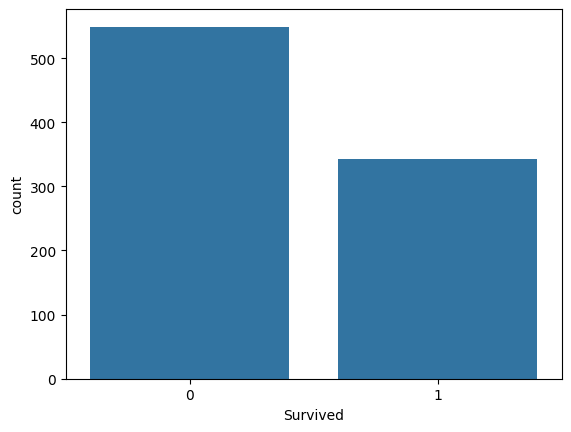

In [29]:
# Countplot for survival
sns.countplot(x="Survived", data=titanic_data)

Text(0, 0.5, 'Number of Passengers')

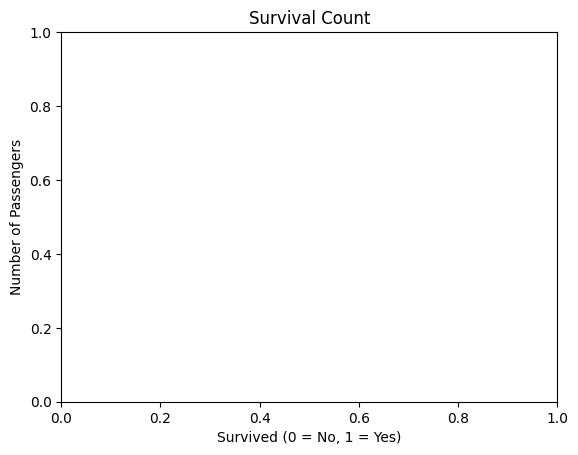

In [31]:
# Add title and labels
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

### Survival Count by Gender

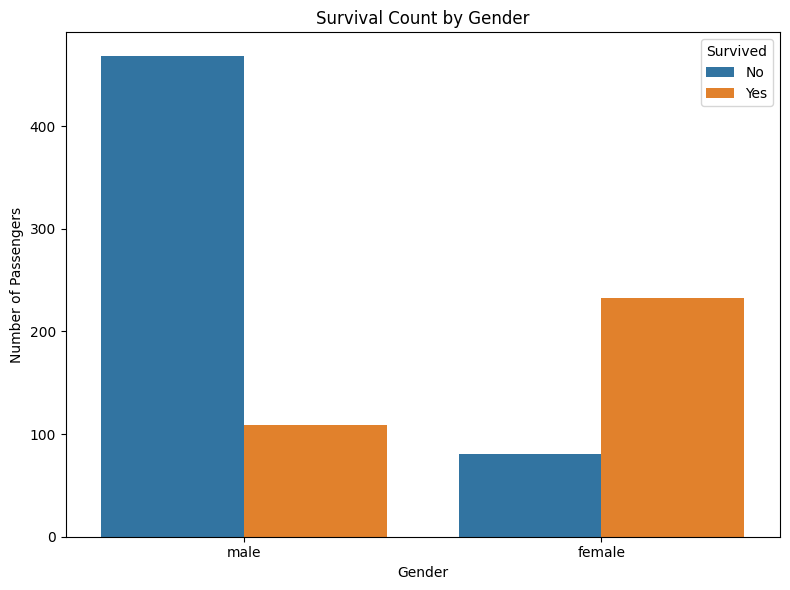

In [41]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(x='Sex', hue='Survived', data=titanic_data, ax=ax)
ax.set_title('Survival Count by Gender')
ax.set_xlabel('Gender')
ax.set_ylabel('Number of Passengers')
ax.legend(title='Survived', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

### Survival Count by Class

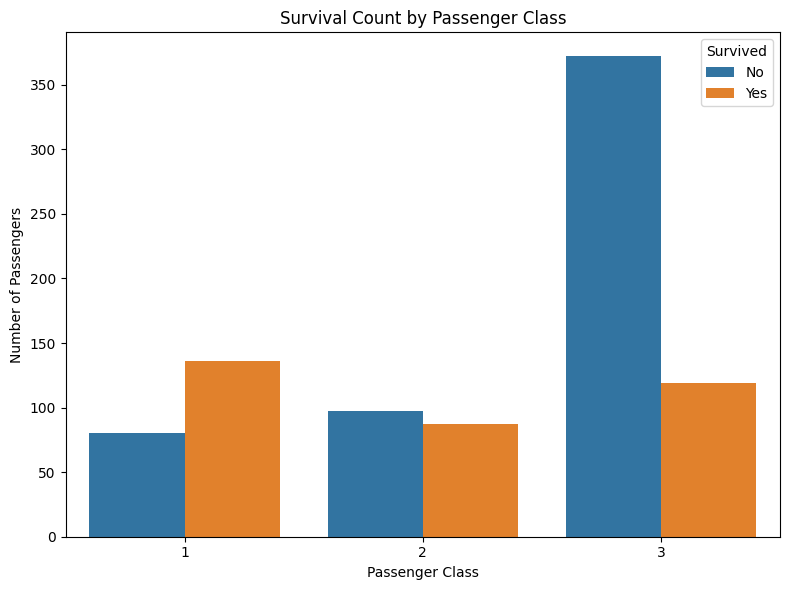

In [42]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(x='Pclass', hue='Survived', data=titanic_data, ax=ax)
ax.set_title('Survival Count by Passenger Class')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Number of Passengers')
ax.legend(title='Survived', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

### Survival Distribution by Age

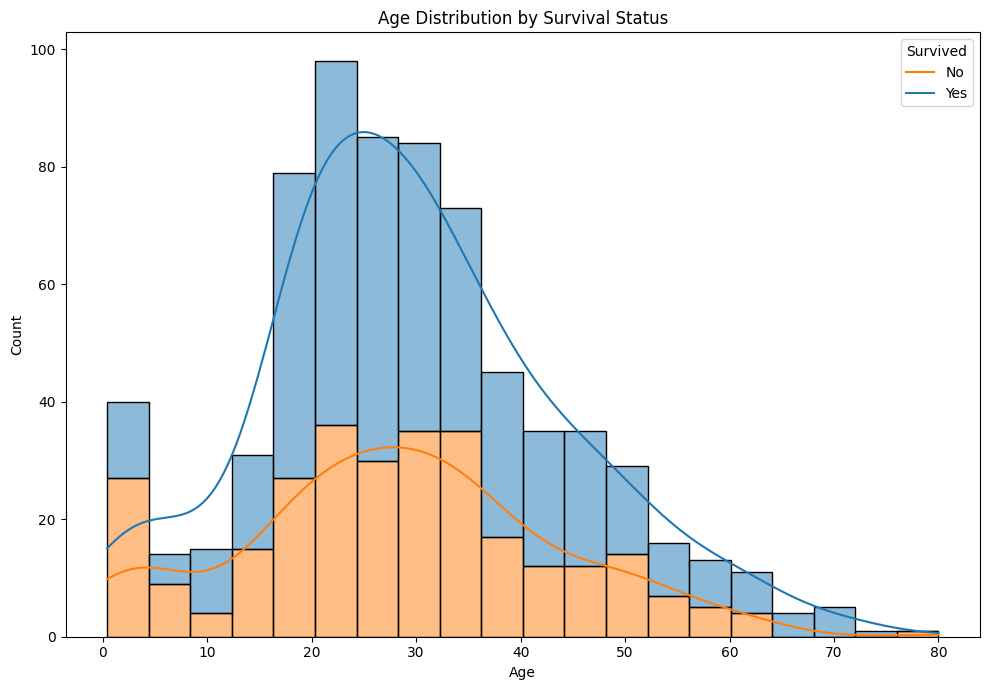

In [43]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.histplot(data=titanic_data, x='Age', hue='Survived', multiple='stack', bins=20, kde=True, ax=ax)
ax.set_title('Age Distribution by Survival Status')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend(title='Survived', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

### Box Plot of Fare

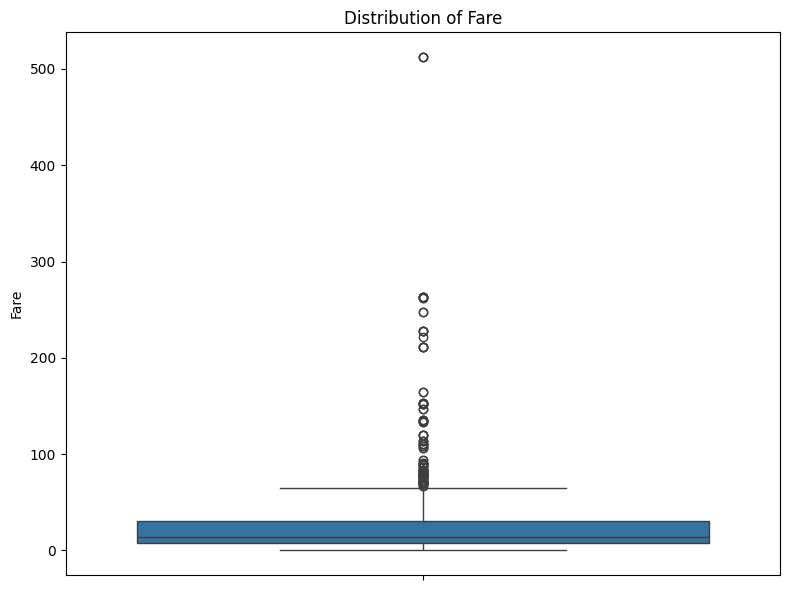

In [45]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(y='Fare', data=titanic_data, ax=ax)
ax.set_title('Distribution of Fare')
ax.set_ylabel('Fare')
plt.tight_layout()
plt.show()